In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from src.constants import (
    TARGET_COL,
    MULTILABEL_COLS,
    CATEGORICAL_COLS,
    CLASS_LABELS,
    RANDOM_STATE,
    CV_SPLITS,
    PROCESSED_DATA_PATH,
)
from src.preprocessing import load_processed_dataset, temporal_train_val_test_split
from src.encoders import fit_mlb_encoder, fit_ohe_encoder, build_mlb_ohe_matrix
from src.evaluation import (
    evaluate_classification_model,
    fit_random_forest_classifier,
    compare_results_table,
)
from src.visualisations import plot_feature_importance, get_original_feature

In [2]:
# Load preprocessed dataset and apply the temporal train/val/test split
df = load_processed_dataset(PROCESSED_DATA_PATH)
df_train, df_val, df_test = temporal_train_val_test_split(df)
#df_train = pd.concat([df_train, df_val], ignore_index=True)

print(f"Training rows : {len(df_train)}")
print(f"Validation rows : {len(df_val)}")
print(f"Test rows : {len(df_test)}")
print(f"\nClass distribution (train):")
print(df_train[TARGET_COL].value_counts())
print(f"\nClass distribution (validation):")
print(df_val[TARGET_COL].value_counts())
print(f"\nClass distribution (test):")
print(df_test[TARGET_COL].value_counts())

Training rows : 6165
Validation rows : 1147
Test rows : 1938

Class distribution (train):
decision_taken
Informal Action Taken    4916
No Further Action         725
Investigation Pursued     524
Name: count, dtype: int64

Class distribution (validation):
decision_taken
Informal Action Taken    918
No Further Action        185
Investigation Pursued     44
Name: count, dtype: int64

Class distribution (test):
decision_taken
Informal Action Taken    1836
No Further Action          72
Investigation Pursued      30
Name: count, dtype: int64


In [3]:
# Fit encoders on training data only
mlb_encoder = fit_mlb_encoder(df_train, MULTILABEL_COLS)
ohe_encoder = fit_ohe_encoder(df_train, CATEGORICAL_COLS)

for col, encoder in mlb_encoder.items():
    print(f"{col}: {len(encoder.classes_)} unique labels")
for col in CATEGORICAL_COLS:
    print(f"{col}: {df_train[col].nunique()} unique values")

data_subject_type: 9 unique labels
data_type: 16 unique labels
incident_category: 2 unique values
incident_type: 21 unique values
no_data_subjects_affected: 7 unique values
time_taken_to_report: 4 unique values


In [4]:
# Build MLB + OHE feature matrices for Random Forest
X_train_ohe = build_mlb_ohe_matrix(df_train, mlb_encoder, ohe_encoder)
X_val_ohe = build_mlb_ohe_matrix(df_val, mlb_encoder, ohe_encoder)
X_test_ohe = build_mlb_ohe_matrix(df_test, mlb_encoder, ohe_encoder)

y_train = df_train[TARGET_COL].reset_index(drop=True)
y_val = df_val[TARGET_COL].reset_index(drop=True)
y_test = df_test[TARGET_COL].reset_index(drop=True)

print(f"X_train_ohe shape: {X_train_ohe.shape}")
print(f"X_val_ohe shape: {X_val_ohe.shape}")
print(f"X_test_ohe shape: {X_test_ohe.shape}")
print(f"\nHead of X_train_ohe:\n {X_train_ohe.head(3).to_string()}")

assert X_train_ohe.isnull().sum().sum() == 0, "Null values found in X_train_ohe"
assert X_val_ohe.isnull().sum().sum() == 0, "Null values found in X_val_ohe"
assert X_test_ohe.isnull().sum().sum() == 0, "Null values found in X_test_ohe"
print("No nulls in feature matrices")

X_train_ohe shape: (6165, 59)
X_val_ohe shape: (1147, 59)
X_test_ohe shape: (1938, 59)

Head of X_train_ohe:
    incident_category_Cyber  incident_category_Non Cyber  incident_type_Alteration of personal data  incident_type_Brute Force  incident_type_Data emailed to incorrect recipient  incident_type_Data of wrong data subject shown in client portal  incident_type_Data posted or faxed to incorrect recipient  incident_type_Denial of service  incident_type_Failure to redact  incident_type_Failure to use bcc  incident_type_Hardware/software misconfiguration  incident_type_Incorrect disposal of hardware  incident_type_Incorrect disposal of paperwork  incident_type_Loss/theft of device containing personal data  incident_type_Loss/theft of paperwork or data left in insecure location  incident_type_Malware  incident_type_Not Provided  incident_type_Other cyber incident  incident_type_Other non-cyber incident  incident_type_Phishing  incident_type_Ransomware  incident_type_Unauthorised access 

Evaluating RF MLB+OHE (Balanced)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.83      0.82      0.82       918
Investigation Pursued       0.11      0.32      0.17        44
    No Further Action       0.32      0.19      0.24       185

             accuracy                           0.70      1147
            macro avg       0.42      0.44      0.41      1147
         weighted avg       0.72      0.70      0.70      1147

Accuracy: 0.6992
Macro F1 Score: 0.4105
Macro Precision: 0.4199
Macro Recall: 0.4440
Macro ROC AUC: 0.6637
Macro PR AUC: 0.4188
Log Loss: 1.3511

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8223, ROC AUC: 0.6546, Brier Score: 0.2005
	Investigation Pursued: F1 Score: 0.1667, ROC AUC: 0.7026, Brier Score: 0.0750
	No Further Action: F1 Score: 0.2424, ROC AUC: 0.6341, Brier Score: 0.1543


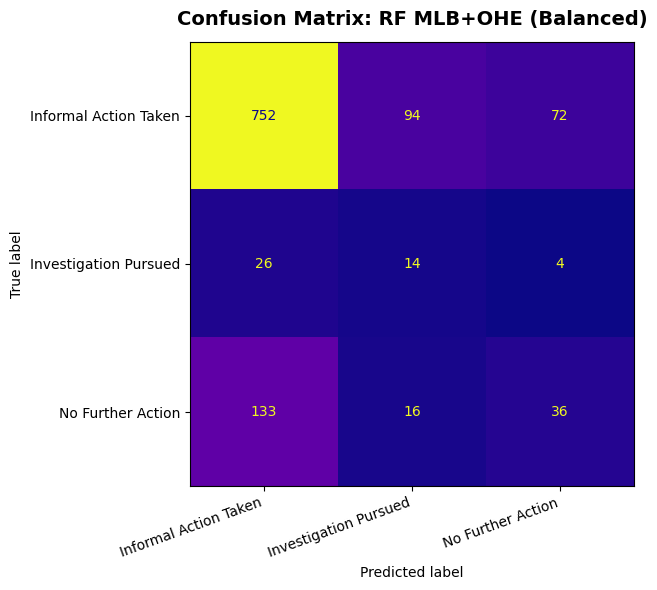

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    752                     94   
Investigation Pursued                     26                     14   
No Further Action                        133                     16   

                       No Further Action  
Informal Action Taken                 72  
Investigation Pursued                  4  
No Further Action                     36  
Evaluating RF MLB+OHE (No Weights)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.83      0.95      0.89       918
Investigation Pursued       0.12      0.11      0.12        44
    No Further Action       0.52      0.17      0.26       185

             accuracy                           0.79      1147
            macro avg       0.49      0.41      0.42      1147
         weighted avg       0.76      0.79      0.76      1147

Accuracy: 0.79

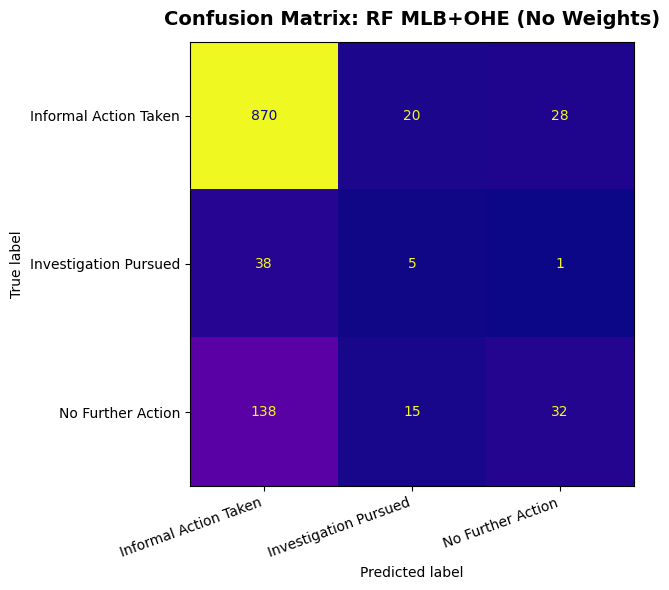

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    870                     20   
Investigation Pursued                     38                      5   
No Further Action                        138                     15   

                       No Further Action  
Informal Action Taken                 28  
Investigation Pursued                  1  
No Further Action                     32  


In [5]:
rf_results = {}
rf_models  = {}

rf_models["baseline"], rf_results["baseline"] = fit_random_forest_classifier(
    "RF MLB+OHE (Balanced)",
    X_train_ohe,
    y_train,
    X_val_ohe,
    y_val,
    class_weights="balanced"
)

rf_models["none"], rf_results["none"] = fit_random_forest_classifier(
    "RF MLB+OHE (No Weights)",
    X_train_ohe,
    y_train,
    X_val_ohe,
    y_val,
    class_weights=None
)

In [6]:
rf_comparison = compare_results_table([rf_results["baseline"],rf_results["none"]])

Metric Headings:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
  RF MLB+OHE (Balanced)  0.699215  0.410466         0.419933      0.443983       0.663747      0.418788  1.351148
RF MLB+OHE (No Weights)  0.790759  0.421719         0.493777      0.411441       0.740246      0.467415  0.977005
Ranked by macro F1 Score:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
RF MLB+OHE (No Weights)  0.790759  0.421719         0.493777      0.411441       0.740246      0.467415  0.977005
  RF MLB+OHE (Balanced)  0.699215  0.410466         0.419933      0.443983       0.663747      0.418788  1.351148
Ranked by macro ROC-AUC:
                  model  accuracy  macro_f1  macro_precision  macro_recall  macro_roc_auc  macro_pr_auc  log_loss
RF MLB+OHE (No Weights)  0.790759  0.421719         0.493777      0.411441       0.740246      0.467415  0.977005
  RF MLB+OHE (Balanc

In [7]:
df_train_val = pd.concat([df_train, df_val], ignore_index=True)
mlb_encoder_final = fit_mlb_encoder(df_train_val, MULTILABEL_COLS)
ohe_encoder_final = fit_ohe_encoder(df_train_val, CATEGORICAL_COLS)

X_train_val_ohe = build_mlb_ohe_matrix(df_train_val, mlb_encoder_final, ohe_encoder_final)
X_test_ohe_final = build_mlb_ohe_matrix(df_test, mlb_encoder_final, ohe_encoder_final)

y_train_val = df_train_val[TARGET_COL].reset_index(drop=True)
y_test = df_test[TARGET_COL].reset_index(drop=True)

In [17]:
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

param_grid = {
    "n_estimators": [50, 100, 300, 500, 700, 1000],
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_leaf": [1, 3, 5]
}

print("RF GridSearchCV grid:")
total_combinations = 1
for key, values in param_grid.items():
    print(f"\t{key}: {values}")
    total_combinations *= len(values)
print(f"Total combinations: {total_combinations} ({total_combinations * CV_SPLITS} fits with {CV_SPLITS}-fold CV)")

rf_tune = RandomForestClassifier(
    max_depth=None,
    class_weight="balanced",
    n_jobs=1,
    random_state=RANDOM_STATE,
)

rf_grid = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=False,
    refit=True,
)

rf_grid.fit(X_train_ohe, y_train)

RF GridSearchCV grid:
	n_estimators: [50, 100, 300, 500, 700, 1000]
	max_features: ['sqrt', 'log2', 0.5]
	min_samples_leaf: [1, 3, 5]
Total combinations: 54 (270 fits with 5-fold CV)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

In [18]:
print("\nBest parameters found:")
for key, value in rf_grid.best_params_.items():
    print(f"\t{key}: {value}")
print(f"Best CV macro F1: {rf_grid.best_score_:.4f}")

# Top 5 combinations for the writeup
rf_cv = pd.DataFrame(rf_grid.cv_results_)
print("\nTop 5 parameter combinations by CV macro F1:")
print(rf_cv[["params", "mean_test_score", "std_test_score"]].sort_values("mean_test_score", ascending=False).head(5).to_string(index=False))


Best parameters found:
	max_features: log2
	min_samples_leaf: 3
	n_estimators: 50
Best CV macro F1: 0.5149

Top 5 parameter combinations by CV macro F1:
                                                               params  mean_test_score  std_test_score
  {'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 50}         0.514851        0.041976
  {'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 50}         0.513383        0.044622
 {'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 100}         0.512035        0.044579
 {'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 300}         0.511594        0.040114
{'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 1000}         0.511346        0.042097


Evaluating RF MLB+OHE: Balanced (TUNED)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.93      0.77      0.84       918
Investigation Pursued       0.10      0.61      0.18        44
    No Further Action       0.46      0.31      0.37       185

             accuracy                           0.69      1147
            macro avg       0.50      0.56      0.46      1147
         weighted avg       0.82      0.69      0.74      1147

Accuracy: 0.6888
Macro F1 Score: 0.4621
Macro Precision: 0.4971
Macro Recall: 0.5636
Macro ROC AUC: 0.7442
Macro PR AUC: 0.4671
Log Loss: 0.8007

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8415, ROC AUC: 0.8098, Brier Score: 0.2188
	Investigation Pursued: F1 Score: 0.1759, ROC AUC: 0.8206, Brier Score: 0.1018
	No Further Action: F1 Score: 0.3689, ROC AUC: 0.6022, Brier Score: 0.1424


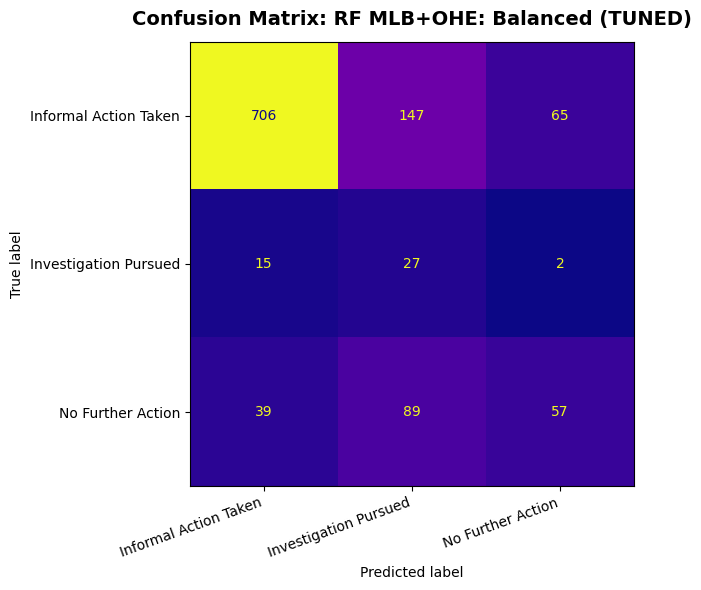

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                    706                    147   
Investigation Pursued                     15                     27   
No Further Action                         39                     89   

                       No Further Action  
Informal Action Taken                 65  
Investigation Pursued                  2  
No Further Action                     57  


{'model': 'RF MLB+OHE: Balanced (TUNED)',
 'accuracy': 0.6887532693984307,
 'macro_f1': 0.4621019180825565,
 'macro_precision': 0.4970954615780221,
 'macro_recall': 0.5636025508574528,
 'macro_roc_auc': 0.7442174423884796,
 'macro_pr_auc': 0.46710581893036096,
 'log_loss': 0.8006708397071548,
 'f1_Informal Action Taken': np.float64(0.8415),
 'roc_auc_Informal Action Taken': 0.8098,
 'brier_Informal Action Taken': 0.2188,
 'f1_Investigation Pursued': np.float64(0.1759),
 'roc_auc_Investigation Pursued': 0.8206,
 'brier_Investigation Pursued': 0.1018,
 'f1_No Further Action': np.float64(0.3689),
 'roc_auc_No Further Action': 0.6022,
 'brier_No Further Action': 0.1424}

In [20]:
best_rf = rf_grid.best_estimator_
evaluate_classification_model(
    "RF MLB+OHE: Balanced (TUNED)",
    best_rf, X_val_ohe, y_val,
)   


 Original feature mapping:
                                                        feature
                                        incident_category_Cyber
                                    incident_category_Non Cyber
                      incident_type_Alteration of personal data
                                      incident_type_Brute Force
              incident_type_Data emailed to incorrect recipient
incident_type_Data of wrong data subject shown in client portal
      incident_type_Data posted or faxed to incorrect recipient
                                incident_type_Denial of service
                                incident_type_Failure to redact
                               incident_type_Failure to use bcc
Feature importance (grouped by original feature):
original_feature
incident_type                0.362504
incident_category            0.211946
no_data_subjects_affected    0.129888
data_subject_type            0.112928
data_type                    0.108847
time_taken_

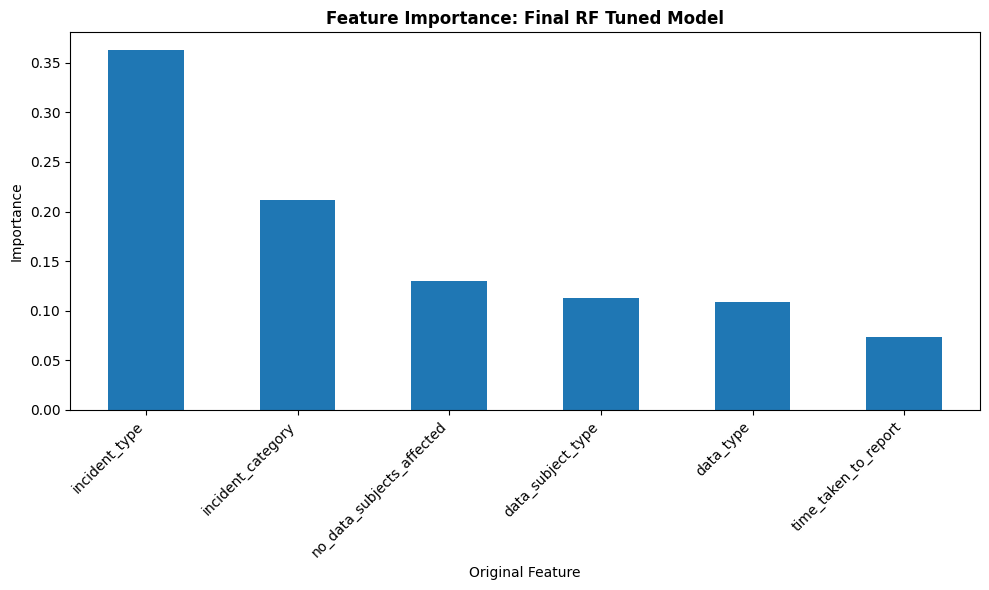

,feature,importance,original_feature
0,incident_category_Cyber,0.082389,incident_category
1,incident_category_Non Cyber,0.129558,incident_category
2,incident_type_Alteration of personal data,0.001805,incident_type
3,incident_type_Brute Force,0.002223,incident_type
4,incident_type_Data emailed to incorrect recipient,0.041280,incident_type
5,incident_type_Data of wrong data subject shown...,0.004343,incident_type
6,incident_type_Data posted or faxed to incorrec...,0.024196,incident_type
7,incident_type_Denial of service,0.000123,incident_type
8,incident_type_Failure to redact,0.005802,incident_type
9,incident_type_Failure to use bcc,0.010421,incident_type


In [21]:
rf_importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": X_train_ohe.columns,
    "importance": rf_importances,
})

print("\n Original feature mapping:")
print(importance_df[["feature"]].head(10).to_string(index=False))

importance_df["original_feature"] = importance_df["feature"].apply(lambda c: get_original_feature(c, CATEGORICAL_COLS))
importance_grouped = importance_df.groupby("original_feature")["importance"].sum().sort_values(ascending=False)

print("Feature importance (grouped by original feature):")
print(importance_grouped.to_string())

print("\nTop 15 raw features (including individual encoded sub-columns):")
print(importance_df.sort_values("importance", ascending=False).head(15).to_string(index=False))

plot_feature_importance(
    rf_importances,
    list(X_train_ohe.columns),
    title="Feature Importance: Final RF Tuned Model",
    categorical_cols=CATEGORICAL_COLS,
    group_by_original_feature=True,
)

In [23]:
final_rf_model = RandomForestClassifier(
    **rf_grid.best_params_,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

final_rf_model.fit(X_train_ohe, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Evaluating RF MLB+OHE: No Weights (TUNED)


Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.97      0.77      0.86      1836
Investigation Pursued       0.02      0.23      0.04        30
    No Further Action       0.21      0.57      0.30        72

             accuracy                           0.76      1938
            macro avg       0.40      0.52      0.40      1938
         weighted avg       0.93      0.76      0.83      1938

Accuracy: 0.7554
Macro F1 Score: 0.4026
Macro Precision: 0.4015
Macro Recall: 0.5247
Macro ROC AUC: 0.7608
Macro PR AUC: 0.4147
Log Loss: 0.6960

Per-Class F1 Scores:
	Informal Action Taken: F1 Score: 0.8608, ROC AUC: 0.7858, Brier Score: 0.2319
	Investigation Pursued: F1 Score: 0.0444, ROC AUC: 0.6725, Brier Score: 0.0813
	No Further Action: F1 Score: 0.3026, ROC AUC: 0.8240, Brier Score: 0.0860


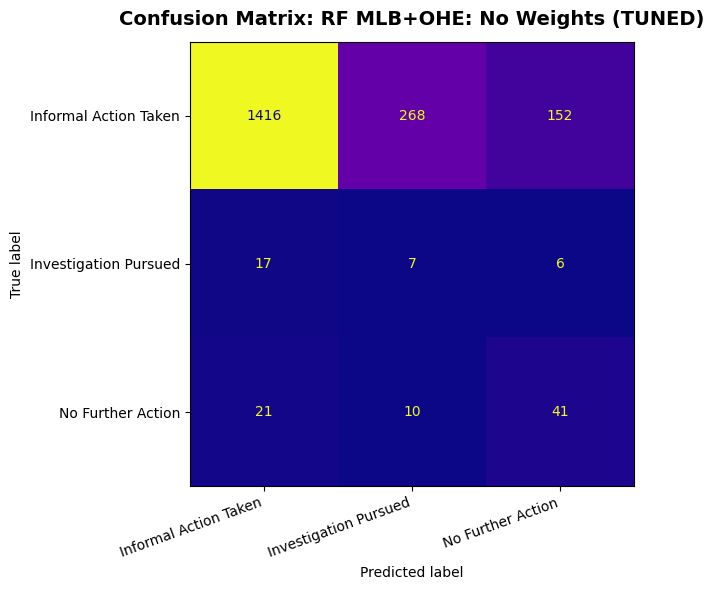

Confusion Matrix table:

                       Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1416                    268   
Investigation Pursued                     17                      7   
No Further Action                         21                     10   

                       No Further Action  
Informal Action Taken                152  
Investigation Pursued                  6  
No Further Action                     41  


In [24]:
final_rf_results = evaluate_classification_model(
    "RF MLB+OHE: No Weights (TUNED)",
    final_rf_model, X_test_ohe_final, y_test,
)